In [1]:
graph2 = {
    'A': [('B', 6), ('C', 3)],
    'B': [('A', 6), ('C', 2), ('D', 5)],
    'C': [('A', 3), ('B', 2), ('D', 3)],
    'D': [('B', 5), ('C', 3)]
}

parcels2 = [
    {"id": 101, "weight": 4, "profit": 40, "location": 'B'},
    {"id": 102, "weight": 6, "profit": 60, "location": 'C'},
    {"id": 103, "weight": 5, "profit": 50, "location": 'D'}
]

capacity2 = 10

In [2]:
def recursive_cost(path, graph, index=0):
    if index == len(path) - 1:
        return 0
    
    current = path[index]
    next_node = path[index + 1]
    
    for neighbor, cost in graph[current]:
        if neighbor == next_node:
            return cost + recursive_cost(path, graph, index + 1)

    return float('inf')


route = ['A', 'C', 'D']
print("Route Cost:", recursive_cost(route, graph2))

Route Cost: 6


In [3]:
def greedy_profit(parcels, capacity):
    parcels.sort(key=lambda x: x["profit"]/x["weight"], reverse=True)
    
    chosen = []
    total_w = 0
    
    for p in parcels:
        if total_w + p["weight"] <= capacity:
            chosen.append(p)
            total_w += p["weight"]
    
    return chosen

print("Selected Parcels:", greedy_profit(parcels2, capacity2))

Selected Parcels: [{'id': 101, 'weight': 4, 'profit': 40, 'location': 'B'}, {'id': 102, 'weight': 6, 'profit': 60, 'location': 'C'}]


In [4]:
def dp_profit(parcels, capacity):
    n = len(parcels)
    dp = [[0]*(capacity+1) for _ in range(n+1)]
    
    for i in range(1, n+1):
        w = parcels[i-1]["weight"]
        val = parcels[i-1]["profit"]
        
        for c in range(capacity+1):
            if w <= c:
                dp[i][c] = max(dp[i-1][c], val + dp[i-1][c-w])
            else:
                dp[i][c] = dp[i-1][c]
    
    return dp[n][capacity]

print("Max Profit:", dp_profit(parcels2, capacity2))

Max Profit: 100


In [5]:
import heapq

def prim_mst(graph):
    start = list(graph.keys())[0]
    visited = set([start])
    pq = [(cost, start, node) for node, cost in graph[start]]
    heapq.heapify(pq)

    total_cost = 0
    mst_edges = []

    while pq:
        cost, frm, to = heapq.heappop(pq)
        
        if to not in visited:
            visited.add(to)
            total_cost += cost
            mst_edges.append((frm, to, cost))
            
            for neighbor, wt in graph[to]:
                if neighbor not in visited:
                    heapq.heappush(pq, (wt, to, neighbor))

    return mst_edges, total_cost

edges, cost = prim_mst(graph2)

print("MST Edges:", edges)
print("Total MST Cost:", cost)

MST Edges: [('A', 'C', 3), ('C', 'B', 2), ('C', 'D', 3)]
Total MST Cost: 8


In [6]:
import itertools

def tsp_v2(graph):
    nodes = list(graph.keys())
    best_cost = float('inf')
    best_path = None

    for perm in itertools.permutations(nodes):
        cost = 0
        
        for i in range(len(perm)-1):
            for nbr, wt in graph[perm[i]]:
                if nbr == perm[i+1]:
                    cost += wt
        
        if cost < best_cost:
            best_cost = cost
            best_path = perm

    return best_path, best_cost

path, cost = tsp_v2(graph2)

print("Optimal Path:", path)
print("Cost:", cost)

Optimal Path: ('A', 'D', 'C', 'B')
Cost: 5


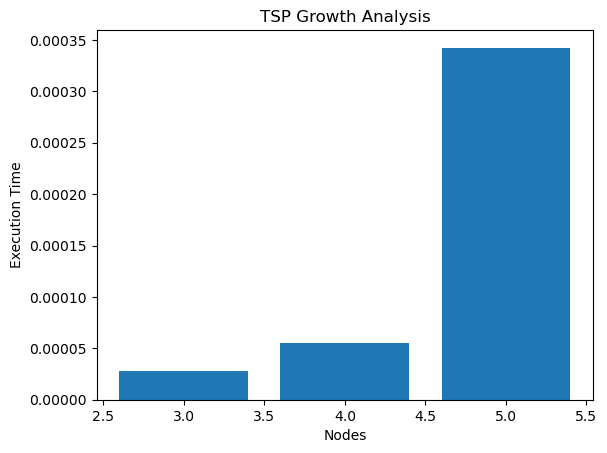

In [7]:
import matplotlib.pyplot as plt
import time

nodes = [3, 4, 5]
times = []

for n in nodes:
    g = {i: [(j, 1) for j in range(n) if j != i] for i in range(n)}
    
    start = time.time()
    tsp_v2(g)
    times.append(time.time() - start)

plt.bar(nodes, times)
plt.xlabel("Nodes")
plt.ylabel("Execution Time")
plt.title("TSP Growth Analysis")
plt.show()